# B5 – Diagnostic Tests for NARDL Models

Tests thực hiện:
- **Breusch-Godfrey** – Serial correlation (LM test)
- **ARCH** – Heteroscedasticity
- **Ramsey RESET** – Functional misspecification
- **CUSUM / CUSUM²** – Parameter stability

> File này gọi lại kết quả từ bước ARDL Estimation (B4), tái ước lượng model và chạy toàn bộ diagnostic.

In [2]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from statsmodels.tsa.ardl import ARDL
from statsmodels.stats.diagnostic import (
    acorr_breusch_godfrey,
    het_arch
)
from statsmodels.stats.stattools import durbin_watson
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load dữ liệu & cấu hình model

In [3]:
data_file = "../data/processed/data_processed.csv"
data_processed = pd.read_csv(data_file)

output_folder = "../results"
os.makedirs(output_folder, exist_ok=True)
diag_folder = os.path.join(output_folder, "diagnostics")
os.makedirs(diag_folder, exist_ok=True)

print(f"Data shape: {data_processed.shape}")
data_processed.head(3)

Data shape: (132, 11)


,ln_FDI,ln_TB,ln_EX,ln_IM,ln_RER_pos,ln_RER_neg,IPI_VN,IPI_World_diff,ln_WTI,ln_M2_diff,COVID
0,0.008915,0.056151,16.664659,16.608507,0.000000,0.000000,100.000000,NaN,3.854818,NaN,0
1,0.031377,-0.020926,16.308444,16.329370,0.000000,0.006208,90.472674,NaN,3.923556,0.001426,0
2,0.009129,-0.040911,16.643582,16.684493,0.000626,0.000000,94.531437,0.040182,3.867444,-0.000088,0


In [4]:
# ============================================================
# Cấu hình models – giữ nguyên từ B4
# ============================================================
models = {
    "Model_2_EX": {
        "dep_var": "ln_EX",
        "exog_vars": ["ln_RER_pos","ln_RER_neg","ln_FDI","IPI_VN",
                      "IPI_World_GR_diff","ln_M2_diff","ln_WTI","COVID"],
        "lag_dep": 6,
        "lag_exog": [3, 1, 6, 6, 5, 2, 0]
    },
    "Model_3_IM": {
        "dep_var": "ln_IM",
        "exog_vars": ["ln_RER_pos","ln_RER_neg","ln_FDI","IPI_VN",
                      "IPI_World_GR_diff","ln_M2_diff","ln_WTI","COVID"],
        "lag_dep": 3,
        "lag_exog": [3, 1, 2, 2, 4, 3, 0]
    }
}

## 2. Helper functions

In [5]:
def create_lags(df, var_list, lag_list):
    """Tạo lag thủ công cho exogenous variables."""
    df_lagged = df.copy()
    for var, lag in zip(var_list, lag_list):
        if lag > 0:
            for l in range(1, lag + 1):
                df_lagged[f"{var}_L{l}"] = df_lagged[var].shift(l)
    return df_lagged


def fit_nardl(spec, data):
    """Fit ARDL/NARDL model và trả về (model, result, df_model)."""
    dep = spec["dep_var"]
    exogs = [v for v in spec["exog_vars"] if v in data.columns]
    df_model = data[[dep] + exogs].dropna()
    df_model = create_lags(df_model, exogs, spec["lag_exog"])
    df_model = df_model.dropna()
    exog_lagged_vars = [col for col in df_model.columns if col != dep]
    model = ARDL(df_model[dep], lags=spec["lag_dep"],
                 exog=df_model[exog_lagged_vars], trend='c')
    res = model.fit()
    return model, res, df_model


def ramsey_reset(res, power=3):
    """
    Ramsey RESET test – phiên bản robust cho ARDL/NARDL.

    Fix (ValueError: exog_oos / matmul dimension mismatch):
        Không dùng res.fittedvalues / res.resid (trigger predict() nội bộ).
        Không dùng res.model.exog (raw exog, chưa gồm lagged endog → sai shape).
        Dùng res.model._x (trimmed design matrix sau khi ARDL drop lags)
        và res.model._y (trimmed endog) — đảm bảo shape khớp 100% với params.

    Returns: (F_stat, p_value, df_num, df_denom)
    """
    from scipy import stats

    # _x: (n_eff, k) trimmed design matrix, _y: (n_eff,) trimmed endog
    # Đây là cặp duy nhất đảm bảo: _x.shape[1] == len(params)
    X_eff  = np.asarray(res.model._x)     # (n_eff, k)
    y_eff  = np.asarray(res.model._y)     # (n_eff,)
    params = np.asarray(res.params)       # (k,)

    fitted = X_eff @ params               # (n_eff,)
    resid  = y_eff - fitted               # (n_eff,)
    n      = len(fitted)

    # y = fitted + resid  (= y_eff, tái tạo để rõ ràng)
    y = fitted + resid                    # shape (n,) — guaranteed aligned

    # Restricted model: y ~ const + fitted  (k_r = 2)
    X_r   = np.column_stack([np.ones(n), fitted])
    res_r = OLS(y, X_r).fit()
    k_r   = X_r.shape[1]

    # Augmented model: thêm fitted^2, fitted^3, ..., fitted^power
    power_terms = [fitted ** p for p in range(2, power + 1)]
    X_aug  = np.column_stack([X_r] + power_terms)  # shape (n, k_r + power-1)
    res_aug = OLS(y, X_aug).fit()

    df_num   = power - 1                          # số biến thêm vào
    df_denom = n - k_r - df_num                   # residual df

    RSS_r = np.sum(res_r.resid ** 2)
    RSS_u = np.sum(res_aug.resid ** 2)

    if RSS_u <= 0 or df_denom <= 0:
        return np.nan, np.nan, df_num, df_denom

    F_stat  = ((RSS_r - RSS_u) / df_num) / (RSS_u / df_denom)
    p_value = 1 - stats.f.cdf(F_stat, df_num, df_denom)
    return F_stat, p_value, df_num, df_denom


def interpret(p, alpha=0.05):
    return "Reject H0 ✗" if p < alpha else "Fail to reject H0 ✓"


print('Helper functions defined ✓')

Helper functions defined ✓


## 3. Chạy Diagnostic Tests

In [7]:
from scipy import stats as scipy_stats


def _get_resid_fitted(res):
    """
    Lấy residuals và fitted values từ ARDLResults một cách an toàn.

    Root cause của 2 lỗi trước:
      1. res.resid / res.fittedvalues  → trigger predict() → exog_oos error
      2. res.model.exog @ params       → matmul mismatch vì model.exog là raw
         exog input của user (chỉ exogenous vars), chưa gồm lagged endog terms
         → số cột (37) ≠ len(params) (30)

    Fix dứt điểm:
      Dùng res.model._x (trimmed full design matrix, gồm cả lagged endog,
      lagged exog, và trend) và res.model._y (trimmed endog).
      ARDL (kế thừa AutoReg) set self._x = x và self._y = y trong _fit(),
      đảm bảo _x.shape[1] == len(params) tuyệt đối.
    """
    X_eff  = np.asarray(res.model._x)   # (n_eff, k) — trimmed design matrix
    y_eff  = np.asarray(res.model._y)   # (n_eff,)   — trimmed endog
    params = np.asarray(res.params)     # (k,)

    fitted = X_eff @ params             # (n_eff,) — no shape mismatch
    resid  = y_eff - fitted             # (n_eff,)
    return resid, fitted


def breusch_godfrey_manual(res, nlags=4):
    """
    Breusch-Godfrey LM test tự cài — tương thích với ARDLResults.

    Không dùng res.fittedvalues / res.resid trực tiếp vì chúng trigger
    predict() nội bộ gây lỗi exog_oos với ARDLResults.
    Thay bằng _get_resid_fitted() tính thủ công từ model matrix.

    Cách làm chuẩn (Greene 2012, ch.12):
      1. Lấy resid e_t và fitted y_hat từ model gốc
      2. Regress e_t ~ [const, y_hat, e_{t-1}, ..., e_{t-p}]
      3. LM = n_eff * R²_aux  ~  chi2(p)
      4. F-version tính từ R² phụ
    """
    e, fitted = _get_resid_fitted(res)
    n = len(e)

    # Tạo lag residuals với zero-padding ở đầu
    lag_cols = [np.concatenate([np.zeros(l), e[:-l]]) for l in range(1, nlags + 1)]
    X_aux = np.column_stack([np.ones(n), fitted] + lag_cols)  # (n, 2+nlags)

    # Bỏ nlags rows đầu để tránh zero-padding làm lệch R²
    X_aux  = X_aux[nlags:]
    e_trim = e[nlags:]
    n_eff  = len(e_trim)

    aux_res = OLS(e_trim, X_aux).fit()
    R2      = aux_res.rsquared

    lm_stat = n_eff * R2
    lm_p    = 1 - scipy_stats.chi2.cdf(lm_stat, df=nlags)

    k_aux    = X_aux.shape[1]
    df_num   = nlags
    df_denom = n_eff - k_aux
    if df_denom > 0 and R2 < 1:
        F_stat = (R2 / df_num) / ((1 - R2) / df_denom)
        F_p    = 1 - scipy_stats.f.cdf(F_stat, df_num, df_denom)
    else:
        F_stat, F_p = np.nan, np.nan

    return lm_stat, lm_p, F_stat, F_p


# ============================================================
all_diag_results = {}

for model_name, spec in models.items():
    print("" + "="*70)
    print(f"  DIAGNOSTIC TESTS — {model_name}")
    print("="*70)

    _, res, _ = fit_nardl(spec, data_processed)

    # Lấy residuals an toàn — KHÔNG dùng res.resid.values trực tiếp
    residuals, _ = _get_resid_fitted(res)   # numpy array, guaranteed aligned

    # ----------------------------------------------------------
    # A) Breusch-Godfrey Serial Correlation LM Test (manual)
    # ----------------------------------------------------------
    bg_lags = 4
    bg_lm, bg_p, bg_f, bg_fp = breusch_godfrey_manual(res, nlags=bg_lags)

    print(f"[A] Breusch-Godfrey Serial Correlation (lags={bg_lags})")
    print(f"    LM statistic : {bg_lm:.4f}")
    print(f"    p-value (χ²) : {bg_p:.4f}  → {interpret(bg_p)}")
    print(f"    F statistic  : {bg_f:.4f}")
    print(f"    p-value (F)  : {bg_fp:.4f}")
    print(f"    H0: No serial correlation")

    # ----------------------------------------------------------
    # B) ARCH Test (Heteroscedasticity)
    # ----------------------------------------------------------
    arch_lags = 4
    arch_lm, arch_p, arch_f, arch_fp = het_arch(residuals, nlags=arch_lags)

    print(f"[B] ARCH Test (lags={arch_lags})")
    print(f"    LM statistic : {arch_lm:.4f}")
    print(f"    p-value (χ²) : {arch_p:.4f}  → {interpret(arch_p)}")
    print(f"    F statistic  : {arch_f:.4f}")
    print(f"    p-value (F)  : {arch_fp:.4f}")
    print(f"    H0: No ARCH effects (homoscedastic)")

    # ----------------------------------------------------------
    # C) Ramsey RESET Test
    # ----------------------------------------------------------
    reset_F, reset_p, reset_dfn, reset_dfd = ramsey_reset(res, power=3)

    print(f"[C] Ramsey RESET Test (powers: y_hat^2, y_hat^3)")
    print(f"    F statistic  : {reset_F:.4f}")
    print(f"    p-value (F)  : {reset_p:.4f}  → {interpret(reset_p)}")
    print(f"    df (num/den) : {reset_dfn} / {reset_dfd}")
    print(f"    H0: No functional misspecification")

    # ----------------------------------------------------------
    # D) Durbin-Watson
    # ----------------------------------------------------------
    dw_stat = durbin_watson(residuals)
    print(f"[D] Durbin-Watson statistic: {dw_stat:.4f}")
    print(f"    (Values near 2 → no serial correlation)")

    # Lưu kết quả vào dict
    all_diag_results[model_name] = {
        "BG_LM": bg_lm, "BG_p": bg_p, "BG_F": bg_f, "BG_Fp": bg_fp,
        "ARCH_LM": arch_lm, "ARCH_p": arch_p, "ARCH_F": arch_f, "ARCH_Fp": arch_fp,
        "RESET_F": reset_F, "RESET_p": reset_p,
        "DW": dw_stat,
        "_res_obj": res
    }


  DIAGNOSTIC TESTS — Model_2_EX
[A] Breusch-Godfrey Serial Correlation (lags=4)
    LM statistic : 0.8126
    p-value (χ²) : 0.9368  → Fail to reject H0 ✓
    F statistic  : 0.1939
    p-value (F)  : 0.9411
    H0: No serial correlation
[B] ARCH Test (lags=4)
    LM statistic : 1.5331
    p-value (χ²) : 0.8208  → Fail to reject H0 ✓
    F statistic  : 0.3716
    p-value (F)  : 0.8285
    H0: No ARCH effects (homoscedastic)
[C] Ramsey RESET Test (powers: y_hat^2, y_hat^3)
    F statistic  : 2.2535
    p-value (F)  : 0.1096  → Fail to reject H0 ✓
    df (num/den) : 2 / 115
    H0: No functional misspecification
[D] Durbin-Watson statistic: 2.0853
    (Values near 2 → no serial correlation)
  DIAGNOSTIC TESTS — Model_3_IM
[A] Breusch-Godfrey Serial Correlation (lags=4)
    LM statistic : 0.8294
    p-value (χ²) : 0.9345  → Fail to reject H0 ✓
    F statistic  : 0.1983
    p-value (F)  : 0.9388
    H0: No serial correlation
[B] ARCH Test (lags=4)
    LM statistic : 1.4661
    p-value (χ²) 

## 4. CUSUM & CUSUM² Stability Tests

In [8]:
def compute_cusum(residuals):
    """
    Tính CUSUM recursive residuals.
    Trả về (cusum_series, upper_band, lower_band)
    theo Brown et al. (1975): critical value 5% = ±0.948 * sqrt(n)
    """
    res = residuals.values
    n = len(res)
    sigma = np.std(res, ddof=1)

    # Standardised CUSUM
    S = np.cumsum(res) / (sigma * np.sqrt(n))

    t = np.arange(1, n + 1) / n
    # 5% critical bands: ±(0.948 + 2*0.948*(t − 0.5/n))  [Brown 1975 approximation]
    cv = 0.948
    upper = cv + 2 * cv * (t - 1 / (2 * n))
    lower = -upper
    return S, upper, lower


def compute_cusumsq(residuals):
    """
    Tính CUSUM of Squares.
    Critical bands 5%: từ Ploberger & Krämer (1992).
    """
    res = residuals.values
    n = len(res)

    res_sq_cum = np.cumsum(res ** 2)
    total_sq = res_sq_cum[-1]
    S2 = res_sq_cum / total_sq  # normalised ∈ [0,1]

    t = np.arange(1, n + 1) / n
    # 5% critical band ±c0 around expected line E[S²(t)] = t
    c0 = 1.358 / (np.sqrt(n) + 0.12 + 0.11 / np.sqrt(n))  # Harvey 1990
    upper = np.minimum(t + c0, 1)
    lower = np.maximum(t - c0, 0)
    return S2, upper, lower, t


print('CUSUM functions defined ✓')

CUSUM functions defined ✓


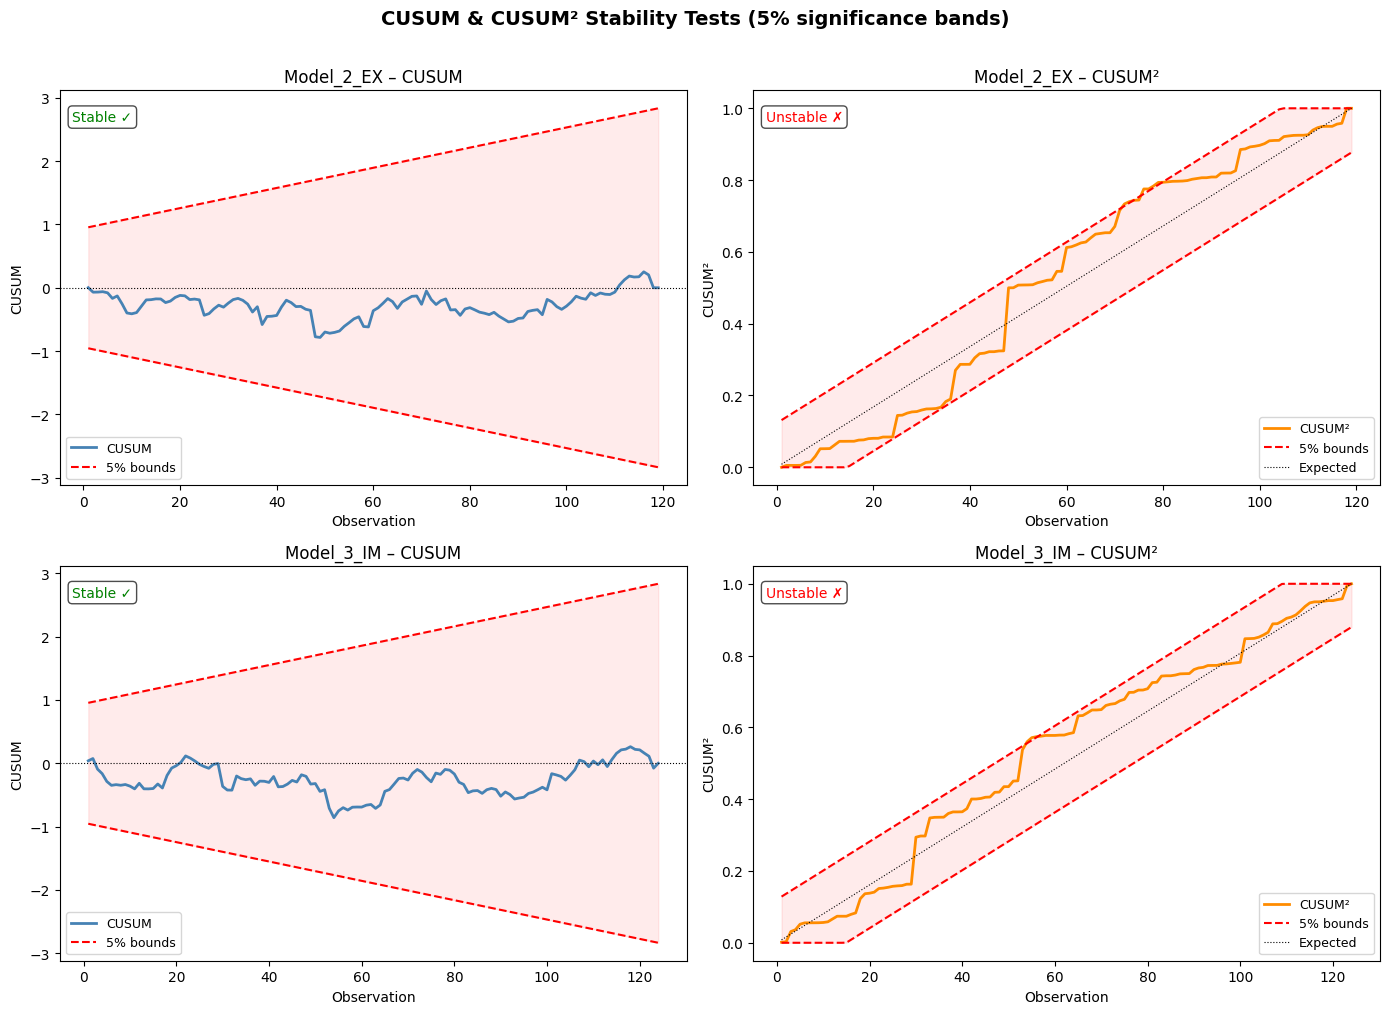


Plots saved → ../results\diagnostics\CUSUM_CUSUMSQ_all_models.png


In [9]:
fig, axes = plt.subplots(nrows=len(models), ncols=2,
                         figsize=(14, 5 * len(models)))
fig.suptitle('CUSUM & CUSUM² Stability Tests (5% significance bands)',
             fontsize=14, fontweight='bold', y=1.01)

cusum_stability = {}

for i, (model_name, diag) in enumerate(all_diag_results.items()):
    res = diag["_res_obj"]
    residuals, _ = _get_resid_fitted(res)  # safe — avoids exog_oos error
    residuals = pd.Series(residuals)  # convert to Series for compute_cusum/cusumsq
    n = len(residuals)
    idx = np.arange(1, n + 1)

    # ---- CUSUM ----
    cusum, upper_c, lower_c = compute_cusum(residuals)
    ax_c = axes[i, 0]
    ax_c.plot(idx, cusum, color='steelblue', lw=2, label='CUSUM')
    ax_c.plot(idx, upper_c, 'r--', lw=1.5, label='5% bounds')
    ax_c.plot(idx, lower_c, 'r--', lw=1.5)
    ax_c.axhline(0, color='black', lw=0.8, linestyle=':')
    ax_c.fill_between(idx, lower_c, upper_c, alpha=0.08, color='red')
    ax_c.set_title(f'{model_name} – CUSUM', fontsize=12)
    ax_c.set_xlabel('Observation')
    ax_c.set_ylabel('CUSUM')
    ax_c.legend(fontsize=9)

    cusum_breach = np.any(cusum > upper_c) or np.any(cusum < lower_c)
    stability_c = "Unstable ✗" if cusum_breach else "Stable ✓"
    ax_c.text(0.02, 0.95, stability_c, transform=ax_c.transAxes,
              fontsize=10, verticalalignment='top',
              color='red' if cusum_breach else 'green',
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    # ---- CUSUM² ----
    cusumsq, upper_sq, lower_sq, t_line = compute_cusumsq(residuals)
    ax_sq = axes[i, 1]
    ax_sq.plot(idx, cusumsq, color='darkorange', lw=2, label='CUSUM²')
    ax_sq.plot(idx, upper_sq, 'r--', lw=1.5, label='5% bounds')
    ax_sq.plot(idx, lower_sq, 'r--', lw=1.5)
    ax_sq.plot(idx, t_line, color='black', lw=0.8, linestyle=':', label='Expected')
    ax_sq.fill_between(idx, lower_sq, upper_sq, alpha=0.08, color='red')
    ax_sq.set_title(f'{model_name} – CUSUM²', fontsize=12)
    ax_sq.set_xlabel('Observation')
    ax_sq.set_ylabel('CUSUM²')
    ax_sq.legend(fontsize=9)

    cusumsq_breach = np.any(cusumsq > upper_sq) or np.any(cusumsq < lower_sq)
    stability_sq = "Unstable ✗" if cusumsq_breach else "Stable ✓"
    ax_sq.text(0.02, 0.95, stability_sq, transform=ax_sq.transAxes,
               fontsize=10, verticalalignment='top',
               color='red' if cusumsq_breach else 'green',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    cusum_stability[model_name] = {
        "CUSUM_stable": not cusum_breach,
        "CUSUMSQ_stable": not cusumsq_breach
    }

plt.tight_layout()
fig_path = os.path.join(diag_folder, "CUSUM_CUSUMSQ_all_models.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPlots saved → {fig_path}")

## 5. Tổng hợp kết quả Diagnostic

In [10]:
summary_rows = []

for model_name, diag in all_diag_results.items():
    stab = cusum_stability[model_name]
    summary_rows.append({
        "Model": model_name,
        # BG
        "BG_LM_stat": round(diag["BG_LM"], 4),
        "BG_p_value": round(diag["BG_p"], 4),
        "BG_result": interpret(diag["BG_p"]),
        # ARCH
        "ARCH_LM_stat": round(diag["ARCH_LM"], 4),
        "ARCH_p_value": round(diag["ARCH_p"], 4),
        "ARCH_result": interpret(diag["ARCH_p"]),
        # RESET
        "RESET_F_stat": round(diag["RESET_F"], 4),
        "RESET_p_value": round(diag["RESET_p"], 4),
        "RESET_result": interpret(diag["RESET_p"]),
        # DW
        "Durbin_Watson": round(diag["DW"], 4),
        # CUSUM
        "CUSUM_stable": "Yes ✓" if stab["CUSUM_stable"] else "No ✗",
        "CUSUMSQ_stable": "Yes ✓" if stab["CUSUMSQ_stable"] else "No ✗",
    })

df_summary = pd.DataFrame(summary_rows).set_index("Model")

print("\n" + "="*80)
print("DIAGNOSTIC TESTS SUMMARY TABLE")
print("="*80)
print(df_summary.T.to_string())

# Xuất CSV
csv_path = os.path.join(diag_folder, "diagnostic_summary.csv")
df_summary.to_csv(csv_path)
print(f"\nSummary saved → {csv_path}")

df_summary.T


DIAGNOSTIC TESTS SUMMARY TABLE
Model                    Model_2_EX           Model_3_IM
BG_LM_stat                   0.8126               0.8294
BG_p_value                   0.9368               0.9345
BG_result       Fail to reject H0 ✓  Fail to reject H0 ✓
ARCH_LM_stat                 1.5331               1.4661
ARCH_p_value                 0.8208               0.8326
ARCH_result     Fail to reject H0 ✓  Fail to reject H0 ✓
RESET_F_stat                 2.2535                2.531
RESET_p_value                0.1096               0.0838
RESET_result    Fail to reject H0 ✓  Fail to reject H0 ✓
Durbin_Watson                2.0853               1.9226
CUSUM_stable                  Yes ✓                Yes ✓
CUSUMSQ_stable                 No ✗                 No ✗

Summary saved → ../results\diagnostics\diagnostic_summary.csv


Model,Model_2_EX,Model_3_IM
BG_LM_stat,0.8126,0.8294
BG_p_value,0.9368,0.9345
BG_result,Fail to reject H0 ✓,Fail to reject H0 ✓
ARCH_LM_stat,1.5331,1.4661
ARCH_p_value,0.8208,0.8326
ARCH_result,Fail to reject H0 ✓,Fail to reject H0 ✓
RESET_F_stat,2.2535,2.531
RESET_p_value,0.1096,0.0838
RESET_result,Fail to reject H0 ✓,Fail to reject H0 ✓
Durbin_Watson,2.0853,1.9226


## 6. Diễn giải kết quả

| Test | H0 | Kết quả mong muốn |
|------|----|-----------------|
| Breusch-Godfrey | Không có serial correlation | p > 0.05 ✓ |
| ARCH | Không có ARCH effects | p > 0.05 ✓ |
| Ramsey RESET | Không sai dạng hàm | p > 0.05 ✓ |
| CUSUM | Ổn định tham số | Trong vùng giới hạn 5% ✓ |
| CUSUM² | Ổn định phương sai | Trong vùng giới hạn 5% ✓ |